# Сетевой анализ персонажей «Перси Джексона»

Полный воспроизводимый анализ первых трёх книг. Узлы = персонажи, рёбра = совместные упоминания в окне ±5 нормализованных строк.

## Исследовательский вопрос

Как меняется структура сети совместных упоминаний персонажей в первых трёх книгах и какие персонажи занимают центральные и посреднические позиции?

In [1]:
from pathlib import Path
import re
import textwrap
from collections import Counter

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network
from IPython.display import display, IFrame

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

RAW_DIR = ROOT / "data/raw"
PROCESSED_DIR = ROOT / "data/processed"
TABLE_DIR = ROOT / "results/tables"
FIGURE_DIR = ROOT / "results/figures"
NETWORK_DIR = ROOT / "results/networks"

for directory in [PROCESSED_DIR, TABLE_DIR, FIGURE_DIR, NETWORK_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

## 1. Словарь персонажей

Разные варианты имени приводятся к одному каноническому имени. Поиск выполняется с учётом регистра, чтобы обычные слова вроде *pan* или *atlas* не считались персонажами (там проблема в том, что такие персонажи ЕСТЬ, но они упомянаются еще как бы в суе).

In [2]:
aliases_df = pd.read_csv(ROOT / "data/characters.csv")
CHARACTERS = (
    aliases_df.groupby("character")["alias"]
    .apply(list)
    .to_dict()
)

def normalize_apostrophes(text):
    return text.replace("’", "'").replace("‘", "'")

def compile_patterns(characters):
    patterns = {}
    for character, aliases in characters.items():
        aliases = sorted(
            {normalize_apostrophes(alias) for alias in aliases},
            key=len,
            reverse=True,
        )
        alternatives = "|".join(re.escape(alias) for alias in aliases)
        patterns[character] = re.compile(
            rf"(?<!\w)(?:{alternatives})(?!\w)"
        )
    return patterns

PATTERNS = compile_patterns(CHARACTERS)
FIRST_PERSON_PATTERN = re.compile(
    r"(?<!\w)(?:I|[Mm]e|[Mm]y|[Mm]ine|[Mm]yself)(?!\w)"
)

print(f"Персонажей в словаре: {len(CHARACTERS)}")
aliases_df.head(10)

Персонажей в словаре: 55


,character,alias
0,Percy Jackson,Percy Jackson
1,Percy Jackson,Perseus Jackson
2,Percy Jackson,Mr. Jackson
3,Percy Jackson,Percy
4,Annabeth Chase,Annabeth Chase
5,Annabeth Chase,Annabeth
6,Grover Underwood,Grover Underwood
7,Grover Underwood,Mr. Underwood
8,Grover Underwood,Grover
9,Chiron,Mr. Brunner


## 2. Выделение основного текста и нормализация строк

Главы определяются по последовательности числительных `ONE`, `TWO` и т. д. Заголовки удаляются, после чего текст каждой главы заново разбивается на строки шириной около 80 символов. Это делает окно сопоставимым между файлами с разной исходной версткой.

In [3]:
CHAPTER_MARKERS = {
    1: ["ONE", "TWO", "THREE", "FOUR", "FIVE", "SIX", "SEVEN",
        "EIGHT", "NINE", "TEN", "ELEVEN", "TWELVE", "THIRTEEN",
        "FOURTEEN", "FIFTEEN", "SIXTEEN", "SEVENTEEN", "EIGHTEEN",
        "NINETEEN", "TWENTY", "TWENTY ONE", "TWENTY TWO"],
    2: ["ONE", "TWO", "THREE", "FOUR", "FIVE", "SIX", "SEVEN",
        "EIGHT", "NINE", "TEN", "ELEVEN", "TWELVE", "THIRTEEN",
        "FOURTEEN", "FIFTEEN", "SIXTEEN", "SEVENTEEN", "EIGHTEEN",
        "NINETEEN", "TWENTY"],
    3: ["ONE", "TWO", "THREE", "FOUR", "FIVE", "SIX", "SEVEN",
        "EIGHT", "NINE", "TEN", "ELEVEN", "TWELVE", "THIRTEEN",
        "FOURTEEN", "FIFTEEN", "SIXTEEN", "SEVENTEEN", "EIGHTEEN",
        "NINETEEN", "TWENTY"],
}

def load_text(path):
    return path.read_text(encoding="utf-8", errors="replace").replace("\x0c", "\n")

def find_sequential_markers(lines, markers):
    positions = []
    cursor = 0
    for marker in markers:
        for line_number in range(cursor, len(lines)):
            if lines[line_number].strip() == marker:
                positions.append(line_number)
                cursor = line_number + 1
                break
        else:
            raise ValueError(f"Не найден маркер главы: {marker}")
    return positions

def extract_chapters(text, book_number, wrap_width=80):
    lines = text.splitlines()
    markers = CHAPTER_MARKERS[book_number]
    positions = find_sequential_markers(lines, markers)

    end_position = len(lines)
    if book_number == 1:
        for line_number in range(positions[-1] + 1, len(lines)):
            if lines[line_number].strip() == "ACKNOWLEDGMENTS":
                end_position = line_number
                break

    chapters = []
    for chapter_index, marker_position in enumerate(positions):
        next_position = (
            positions[chapter_index + 1]
            if chapter_index + 1 < len(positions)
            else end_position
        )
        segment = lines[marker_position + 1:next_position]

        cursor = 0
        while cursor < len(segment) and not segment[cursor].strip():
            cursor += 1
        while cursor < len(segment):
            line = segment[cursor].strip()
            if line and line.upper() == line and re.search(r"[A-Z]", line):
                cursor += 1
            else:
                break

        body_text = " ".join(
            line.strip() for line in segment[cursor:] if line.strip()
        )
        body_text = re.sub(r"\s+", " ", body_text).strip()
        normalized_lines = textwrap.wrap(
            body_text,
            width=wrap_width,
            break_long_words=False,
            break_on_hyphens=False,
        )
        chapters.append(normalized_lines)

    return chapters

In [4]:
books = {}
corpus_rows = []
for book_number in [1, 2, 3]:
    path = RAW_DIR / f"percy_jackson_book_{book_number}.txt"
    if not path.exists():
        raise FileNotFoundError(
            f"Нет файла {path.name}. Смотрите data/raw/README.md"
        )
    chapters = extract_chapters(load_text(path), book_number)
    books[book_number] = chapters
    corpus_rows.append({
        "book": book_number,
        "chapters": len(chapters),
        "normalized_lines": sum(len(chapter) for chapter in chapters),
    })

corpus_stats = pd.DataFrame(corpus_rows)
corpus_stats.to_csv(TABLE_DIR / "corpus_summary.csv", index=False)
corpus_stats

,book,chapters,normalized_lines
0,1,22,6151
1,2,20,4602
2,3,20,5123


## 3. Извлечение совместных упоминаний

Для каждой строки определяется множество упомянутых персонажей. Если строка содержит местоимение первого лица, в неё добавляется Перси. Затем для каждого источника просматривается окно ±5 строк, как в учебном задании.

In [5]:
def characters_in_line(line):
    normalized = normalize_apostrophes(line)
    found = {
        character
        for character, pattern in PATTERNS.items()
        if pattern.search(normalized)
    }
    if FIRST_PERSON_PATTERN.search(normalized):
        found.add("Percy Jackson")
    return found

def build_raw_edges(chapters, book_number, window_size=5):
    rows = []
    for chapter_number, lines in enumerate(chapters, start=1):
        detected = [characters_in_line(line) for line in lines]

        for source_line, source_characters in enumerate(detected):
            if not source_characters:
                continue

            window_start = max(0, source_line - window_size)
            window_end = min(len(lines), source_line + window_size + 1)
            target_counts = Counter()

            for line_number in range(window_start, window_end):
                for target in detected[line_number]:
                    target_counts[target] += 1

            for source in source_characters:
                for target, weight in target_counts.items():
                    if source != target:
                        rows.append({
                            "Source": source,
                            "Target": target,
                            "Weight": weight,
                            "book": book_number,
                            "chapter": chapter_number,
                            "source_line": source_line + 1,
                        })

    return pd.DataFrame(rows)

raw_edges = pd.concat(
    [build_raw_edges(books[book], book) for book in books],
    ignore_index=True,
)
raw_edges.to_csv(PROCESSED_DIR / "raw_cooccurrences.csv", index=False)
print(f"Строк до агрегации: {len(raw_edges):,}")
raw_edges.head()

Строк до агрегации: 48,801


,Source,Target,Weight,book,chapter,source_line
0,Percy Jackson,Chiron,1,1,1,13
1,Percy Jackson,Chiron,2,1,1,17
2,Chiron,Percy Jackson,3,1,1,18
3,Percy Jackson,Chiron,2,1,1,19
4,Chiron,Percy Jackson,3,1,1,19


## 4. Нормализация и агрегация пар

In [6]:
pairs = raw_edges.apply(
    lambda row: sorted([row["Source"], row["Target"]]),
    axis=1,
    result_type="expand",
)
raw_edges["node_1"] = pairs[0]
raw_edges["node_2"] = pairs[1]

edges = (
    raw_edges.groupby(["book", "node_1", "node_2"], as_index=False)["Weight"]
    .sum()
    .rename(columns={
        "node_1": "source",
        "node_2": "target",
        "Weight": "weight",
    })
)
edges.to_csv(PROCESSED_DIR / "edges_by_book.csv", index=False)
print(f"Уникальных рёбер после агрегации: {len(edges):,}")
edges.sort_values("weight", ascending=False).head(10)

Уникальных рёбер после агрегации: 990


,book,source,target,weight
239,1,Grover Underwood,Percy Jackson,5388
345,2,Annabeth Chase,Percy Jackson,5130
39,1,Annabeth Chase,Percy Jackson,4754
969,3,Percy Jackson,Thalia Grace,4496
554,2,Percy Jackson,Tyson,4022
972,3,Percy Jackson,Zoë Nightshade,3812
880,3,Grover Underwood,Percy Jackson,3096
173,1,Chiron,Percy Jackson,2998
603,3,Annabeth Chase,Percy Jackson,2614
306,1,Percy Jackson,Sally Jackson,2138


## 5. Построение графов и расчёт метрик

In [7]:
def build_graph(edge_table):
    graph = nx.Graph()
    for _, row in edge_table.iterrows():
        graph.add_edge(
            row["source"],
            row["target"],
            weight=int(row["weight"]),
        )
    return graph

def calculate_metrics(graph, book_number):
    degree = dict(graph.degree())
    weighted_degree = dict(graph.degree(weight="weight"))
    degree_centrality = nx.degree_centrality(graph)
    betweenness_centrality = nx.betweenness_centrality(graph)

    return pd.DataFrame({
        "book": book_number,
        "character": list(graph.nodes()),
        "degree": [degree[node] for node in graph.nodes()],
        "weighted_degree": [weighted_degree[node] for node in graph.nodes()],
        "degree_centrality": [degree_centrality[node] for node in graph.nodes()],
        "betweenness_centrality": [betweenness_centrality[node] for node in graph.nodes()],
    })

graphs = {}
summary_rows = []
metric_tables = []

for book_number in [1, 2, 3]:
    book_edges = edges[edges["book"] == book_number]
    graph = build_graph(book_edges)
    graphs[book_number] = graph
    summary_rows.append({
        "book": book_number,
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "density": nx.density(graph),
    })
    metric_tables.append(calculate_metrics(graph, book_number))

network_summary = pd.DataFrame(summary_rows)
character_metrics = pd.concat(metric_tables, ignore_index=True)

network_summary.to_csv(TABLE_DIR / "network_summary.csv", index=False)
character_metrics.to_csv(TABLE_DIR / "character_metrics.csv", index=False)
network_summary.round(3)

,book,nodes,edges,density
0,1,35,315,0.529
1,2,34,259,0.462
2,3,41,416,0.507


In [8]:
for book_number in [1, 2, 3]:
    print(f"Книга {book_number}: топ-10 по degree centrality")
    display(
        character_metrics[character_metrics["book"] == book_number]
        .sort_values("degree_centrality", ascending=False)
        .head(10)
        [["character", "degree_centrality", "betweenness_centrality"]]
        .round(3)
    )

Книга 1: топ-10 по degree centrality


,character,degree_centrality,betweenness_centrality
11,Percy Jackson,1.000,0.082
6,Grover Underwood,1.000,0.082
1,Annabeth Chase,0.941,0.067
14,Zeus,0.853,0.032
3,Ares,0.824,0.028
4,Chiron,0.824,0.028
12,Poseidon,0.794,0.031
7,Hades,0.794,0.036
13,Sally Jackson,0.676,0.017
18,Athena,0.618,0.008


Книга 2: топ-10 по degree centrality


,character,degree_centrality,betweenness_centrality
45,Percy Jackson,1.000,0.165
36,Annabeth Chase,0.879,0.067
41,Grover Underwood,0.848,0.061
40,Clarisse La Rue,0.818,0.046
43,Luke Castellan,0.758,0.038
46,Tyson,0.727,0.027
60,Poseidon,0.667,0.021
39,Chiron,0.636,0.013
64,Thalia Grace,0.636,0.015
63,Tantalus,0.606,0.010


Книга 3: топ-10 по degree centrality


,character,degree_centrality,betweenness_centrality
99,Percy Jackson,1.000,0.100
103,Thalia Grace,0.950,0.065
69,Annabeth Chase,0.925,0.051
106,Zoë Nightshade,0.850,0.039
86,Grover Underwood,0.775,0.023
74,Artemis,0.750,0.019
105,Zeus,0.725,0.019
80,Chiron,0.725,0.019
93,Luke Castellan,0.725,0.021
100,Poseidon,0.725,0.029


## 6. Интерактивная визуализация PyVis

Размер узла зависит от degree centrality, толщина ребра — от квадратного корня веса.

In [9]:
import math

MIN_EDGE_WEIGHT = 5     # слабые связи не показываем
MIN_EDGE_WIDTH = 0.5
MAX_EDGE_WIDTH = 5.0

for book_number, original_graph in graphs.items():
    graph = original_graph.copy()

    degree_centrality = nx.degree_centrality(graph)
    betweenness = nx.betweenness_centrality(graph)

    # Стабильное расположение узлов (чтобы у преподавателя не случилось эпилепсии :D)
    positions = nx.spring_layout(
        graph,
        seed=42,
        weight="weight",
        k=1.8,
        iterations=400,
        scale=1200,
    )

    network = Network(
        height="760px",
        width="100%",
        bgcolor="#101522",
        font_color="#f4f4f4",
        directed=False,
        cdn_resources="in_line",
    )

    # Добавляем узлы вручную
    for node in graph.nodes():
        network.add_node(
            node,
            label=node,
            title=(
                f"<b>{node}</b><br>"
                f"Degree centrality: "
                f"{degree_centrality[node]:.3f}<br>"
                f"Betweenness: {betweenness[node]:.3f}"
            ),
            size=10 + degree_centrality[node] * 55,
            x=float(positions[node][0]),
            y=float(positions[node][1]),
            color="#8dbaf2",
            borderWidth=1,
        )

    # Оставляем только достаточно сильные связи
    visible_edges = [
        (source, target, data)
        for source, target, data in graph.edges(data=True)
        if data["weight"] >= MIN_EDGE_WEIGHT
    ]

    if visible_edges:
        visible_weights = [
            math.log1p(data["weight"])
            for _, _, data in visible_edges
        ]

        min_log_weight = min(visible_weights)
        max_log_weight = max(visible_weights)

        for source, target, data in visible_edges:
            log_weight = math.log1p(data["weight"])

            # Нормализуем толщину строго в диапазон 0.5–5
            if max_log_weight == min_log_weight:
                edge_width = 2.0
            else:
                edge_width = (
                    MIN_EDGE_WIDTH
                    + (
                        (log_weight - min_log_weight)
                        / (max_log_weight - min_log_weight)
                    )
                    * (MAX_EDGE_WIDTH - MIN_EDGE_WIDTH)
                )

            network.add_edge(
                source,
                target,
                width=edge_width,
                title=f"Вес связи: {data['weight']}",
                color={
                    "color": "rgba(126, 169, 222, 0.38)",
                    "highlight": "#d6e8ff",
                    "hover": "#d6e8ff",
                },
                smooth=False,
            )

    network.set_options("""
    {
      "physics": {
        "enabled": false
      },
      "interaction": {
        "dragNodes": true,
        "dragView": true,
        "zoomView": true,
        "hover": true,
        "navigationButtons": true
      },
      "nodes": {
        "shape": "dot",
        "font": {
          "size": 13,
          "color": "#f4f4f4",
          "strokeWidth": 3,
          "strokeColor": "#101522"
        }
      },
      "edges": {
        "smooth": false,
        "selectionWidth": 1.5,
        "hoverWidth": 1.5
      }
    }
    """)

    network.write_html(
        str(NETWORK_DIR / f"book_{book_number}_network.html")
    )

print("HTML-сети сохранены в results/networks")

HTML-сети сохранены в results/networks


## 7. Статичные сравнительные графики

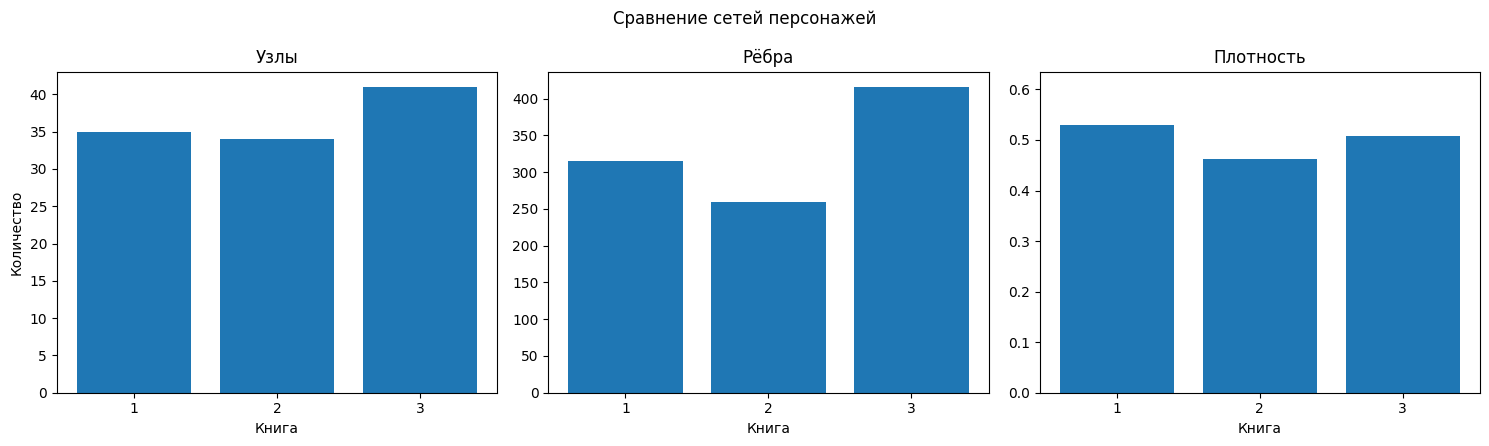

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].bar(network_summary["book"].astype(str), network_summary["nodes"])
axes[0].set_title("Узлы")
axes[0].set_xlabel("Книга")
axes[0].set_ylabel("Количество")

axes[1].bar(network_summary["book"].astype(str), network_summary["edges"])
axes[1].set_title("Рёбра")
axes[1].set_xlabel("Книга")

axes[2].bar(network_summary["book"].astype(str), network_summary["density"])
axes[2].set_title("Плотность")
axes[2].set_xlabel("Книга")
axes[2].set_ylim(0, max(network_summary["density"]) * 1.2)

fig.suptitle("Сравнение сетей персонажей")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "network_summary.png", dpi=180, bbox_inches="tight")
plt.show()

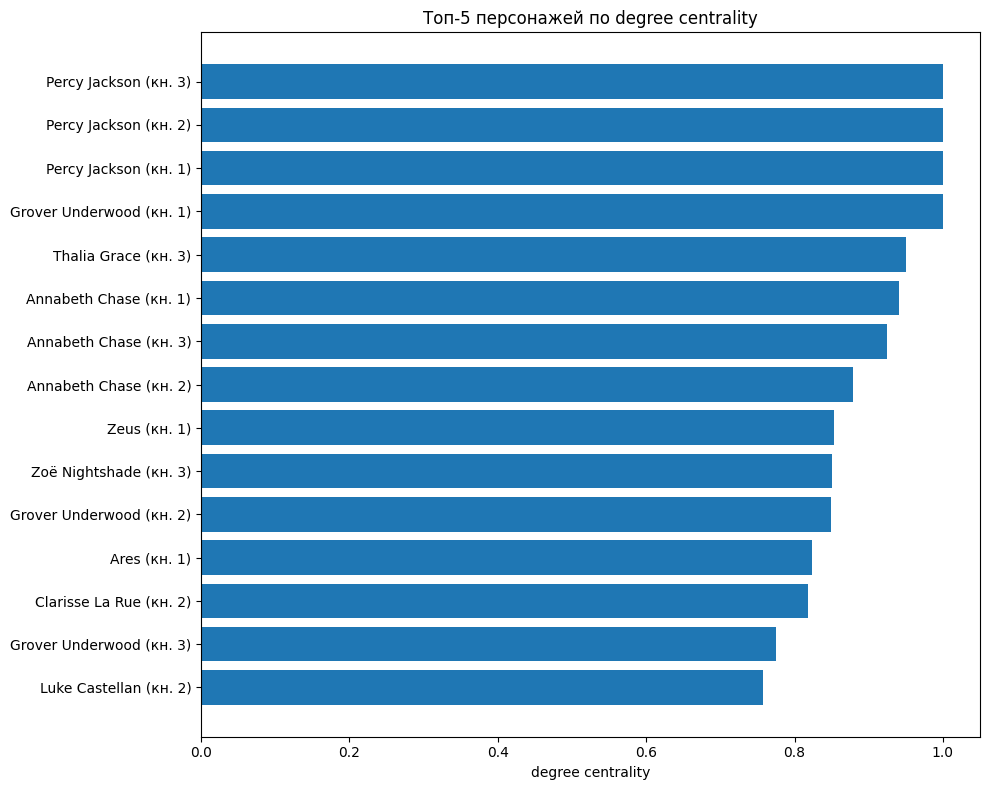

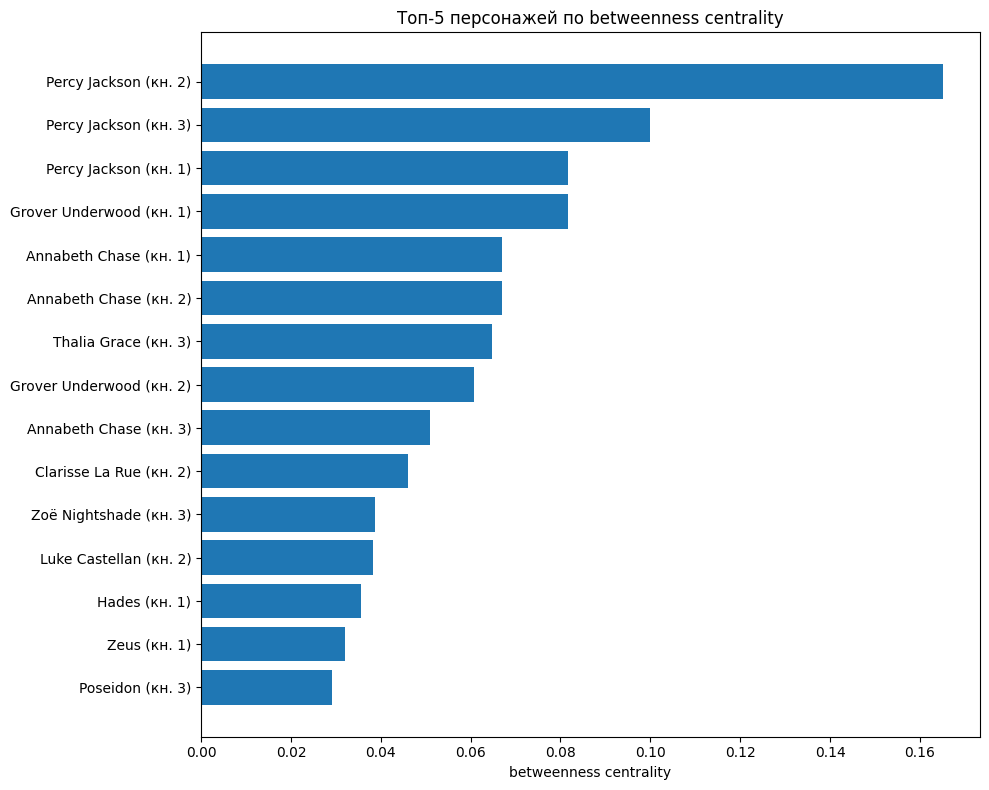

In [11]:
def plot_top_metric(metric, filename, title):
    combined = []
    for book in [1, 2, 3]:
        top = (
            character_metrics[character_metrics["book"] == book]
            .nlargest(5, metric)
            .copy()
        )
        top["label"] = top["character"] + " (кн. " + top["book"].astype(str) + ")"
        combined.append(top)
    plot_data = pd.concat(combined).sort_values(metric)

    plt.figure(figsize=(10, 8))
    plt.barh(plot_data["label"], plot_data[metric])
    plt.xlabel(metric.replace("_", " "))
    plt.title(title)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()

plot_top_metric(
    "degree_centrality",
    "top_degree_by_book.png",
    "Топ-5 персонажей по degree centrality",
)
plot_top_metric(
    "betweenness_centrality",
    "top_betweenness_by_book.png",
    "Топ-5 персонажей по betweenness centrality",
)

## 8. Ограничения

- Совместное упоминание не обязательно означает прямое взаимодействие.
- Первое лицо усиливает позиции Перси.
- Результат зависит от полноты ручного словаря.
- Размер окна влияет на плотность и веса.
- Вес не передаётся напрямую в betweenness, потому что NetworkX трактует его как расстояние, а здесь большой вес означает сильную связь.